# IT3212 - Assignment 1 - Group 44

## Task 1 - Data Exploration

### Dataset overview

In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv("../data/smoking_driking_dataset_Ver01.csv")

# Display the first few rows
df.head()

,sex,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,...,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd,DRK_YN
0,Male,35,170,75,90.0,1.0,1.0,1.0,1.0,120.0,...,126.0,92.0,17.1,1.0,1.0,21.0,35.0,40.0,1.0,Y
1,Male,30,180,80,89.0,0.9,1.2,1.0,1.0,130.0,...,148.0,121.0,15.8,1.0,0.9,20.0,36.0,27.0,3.0,N
2,Male,40,165,75,91.0,1.2,1.5,1.0,1.0,120.0,...,74.0,104.0,15.8,1.0,0.9,47.0,32.0,68.0,1.0,N
3,Male,50,175,80,91.0,1.5,1.2,1.0,1.0,145.0,...,104.0,106.0,17.6,1.0,1.1,29.0,34.0,18.0,1.0,N
4,Male,50,165,60,80.0,1.0,1.2,1.0,1.0,138.0,...,117.0,104.0,13.8,1.0,0.8,19.0,12.0,25.0,1.0,N


In [3]:
# Shape of the dataset (rows, columns)
df.shape

(991346, 24)

In [4]:
# Data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 991346 entries, 0 to 991345
Data columns (total 24 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   sex               991346 non-null  str    
 1   age               991346 non-null  int64  
 2   height            991346 non-null  int64  
 3   weight            991346 non-null  int64  
 4   waistline         991346 non-null  float64
 5   sight_left        991346 non-null  float64
 6   sight_right       991346 non-null  float64
 7   hear_left         991346 non-null  float64
 8   hear_right        991346 non-null  float64
 9   SBP               991346 non-null  float64
 10  DBP               991346 non-null  float64
 11  BLDS              991346 non-null  float64
 12  tot_chole         991346 non-null  float64
 13  HDL_chole         991346 non-null  float64
 14  LDL_chole         991346 non-null  float64
 15  triglyceride      991346 non-null  float64
 16  hemoglobin        991346 non-nu

### Summary statistics

In [5]:
# Summary statistics for numerical columns
df.describe()

,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,DBP,...,HDL_chole,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd
count,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,...,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000
mean,47.614491,162.240625,63.284050,81.233358,0.980834,0.978429,1.031495,1.030476,122.432498,76.052627,...,56.936800,113.037692,132.141751,14.229824,1.094224,0.860467,25.989308,25.755051,37.136347,1.608122
std,14.181339,9.282957,12.514241,11.850323,0.605949,0.604774,0.174650,0.171892,14.543148,9.889365,...,17.238479,35.842812,102.196985,1.584929,0.437724,0.480530,23.493386,26.308599,50.424153,0.818507
min,20.000000,130.000000,25.000000,8.000000,0.100000,0.100000,1.000000,1.000000,67.000000,32.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.100000,1.000000,1.000000,1.000000,1.000000
25%,35.000000,155.000000,55.000000,74.100000,0.700000,0.700000,1.000000,1.000000,112.000000,70.000000,...,46.000000,89.000000,73.000000,13.200000,1.000000,0.700000,19.000000,15.000000,16.000000,1.000000
50%,45.000000,160.000000,60.000000,81.000000,1.000000,1.000000,1.000000,1.000000,120.000000,76.000000,...,55.000000,111.000000,106.000000,14.300000,1.000000,0.800000,23.000000,20.000000,23.000000,1.000000
75%,60.000000,170.000000,70.000000,87.800000,1.200000,1.200000,1.000000,1.000000,131.000000,82.000000,...,66.000000,135.000000,159.000000,15.400000,1.000000,1.000000,28.000000,29.000000,39.000000,2.000000
max,85.000000,190.000000,140.000000,999.000000,9.900000,9.900000,2.000000,2.000000,273.000000,185.000000,...,8110.000000,5119.000000,9490.000000,25.000000,6.000000,98.000000,9999.000000,7210.000000,999.000000,3.000000


In [6]:
# Columns that are numerically coded but actually categorical
coded_categorical = ['hear_left', 'hear_right', 'urine_protein', 'SMK_stat_type_cd']

# True continuous numerical columns
continuous_cols = [col for col in df.select_dtypes(include='number').columns if col not in coded_categorical]

df[continuous_cols].describe()

,age,height,weight,waistline,sight_left,sight_right,SBP,DBP,BLDS,tot_chole,HDL_chole,LDL_chole,triglyceride,hemoglobin,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP
count,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000
mean,47.614491,162.240625,63.284050,81.233358,0.980834,0.978429,122.432498,76.052627,100.424447,195.557020,56.936800,113.037692,132.141751,14.229824,0.860467,25.989308,25.755051,37.136347
std,14.181339,9.282957,12.514241,11.850323,0.605949,0.604774,14.543148,9.889365,24.179960,38.660155,17.238479,35.842812,102.196985,1.584929,0.480530,23.493386,26.308599,50.424153
min,20.000000,130.000000,25.000000,8.000000,0.100000,0.100000,67.000000,32.000000,25.000000,30.000000,1.000000,1.000000,1.000000,1.000000,0.100000,1.000000,1.000000,1.000000
25%,35.000000,155.000000,55.000000,74.100000,0.700000,0.700000,112.000000,70.000000,88.000000,169.000000,46.000000,89.000000,73.000000,13.200000,0.700000,19.000000,15.000000,16.000000
50%,45.000000,160.000000,60.000000,81.000000,1.000000,1.000000,120.000000,76.000000,96.000000,193.000000,55.000000,111.000000,106.000000,14.300000,0.800000,23.000000,20.000000,23.000000
75%,60.000000,170.000000,70.000000,87.800000,1.200000,1.200000,131.000000,82.000000,105.000000,219.000000,66.000000,135.000000,159.000000,15.400000,1.000000,28.000000,29.000000,39.000000
max,85.000000,190.000000,140.000000,999.000000,9.900000,9.900000,273.000000,185.000000,852.000000,2344.000000,8110.000000,5119.000000,9490.000000,25.000000,98.000000,9999.000000,7210.000000,999.000000


### Missing values and duplicates

In [7]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 26


### Categorical value counts

In [8]:
# True categorical columns
print(df['sex'].value_counts())
print()
print(df['DRK_YN'].value_counts())

sex
Male      526415
Female    464931
Name: count, dtype: int64

DRK_YN
N    495858
Y    495488
Name: count, dtype: int64


In [9]:
# Coded categorical columns
for col in coded_categorical:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

--- hear_left ---
hear_left
1.0    960124
2.0     31222
Name: count, dtype: int64

--- hear_right ---
hear_right
1.0    961134
2.0     30212
Name: count, dtype: int64

--- urine_protein ---
urine_protein
1.0    935175
2.0     30850
3.0     16405
4.0      6427
5.0      1977
6.0       512
Name: count, dtype: int64

--- SMK_stat_type_cd ---
SMK_stat_type_cd
1.0    602441
3.0    213954
2.0    174951
Name: count, dtype: int64



## Task 2 - Data Cleaning

## Task 3 - Handling Outliers

### Visualize outliers with boxplots

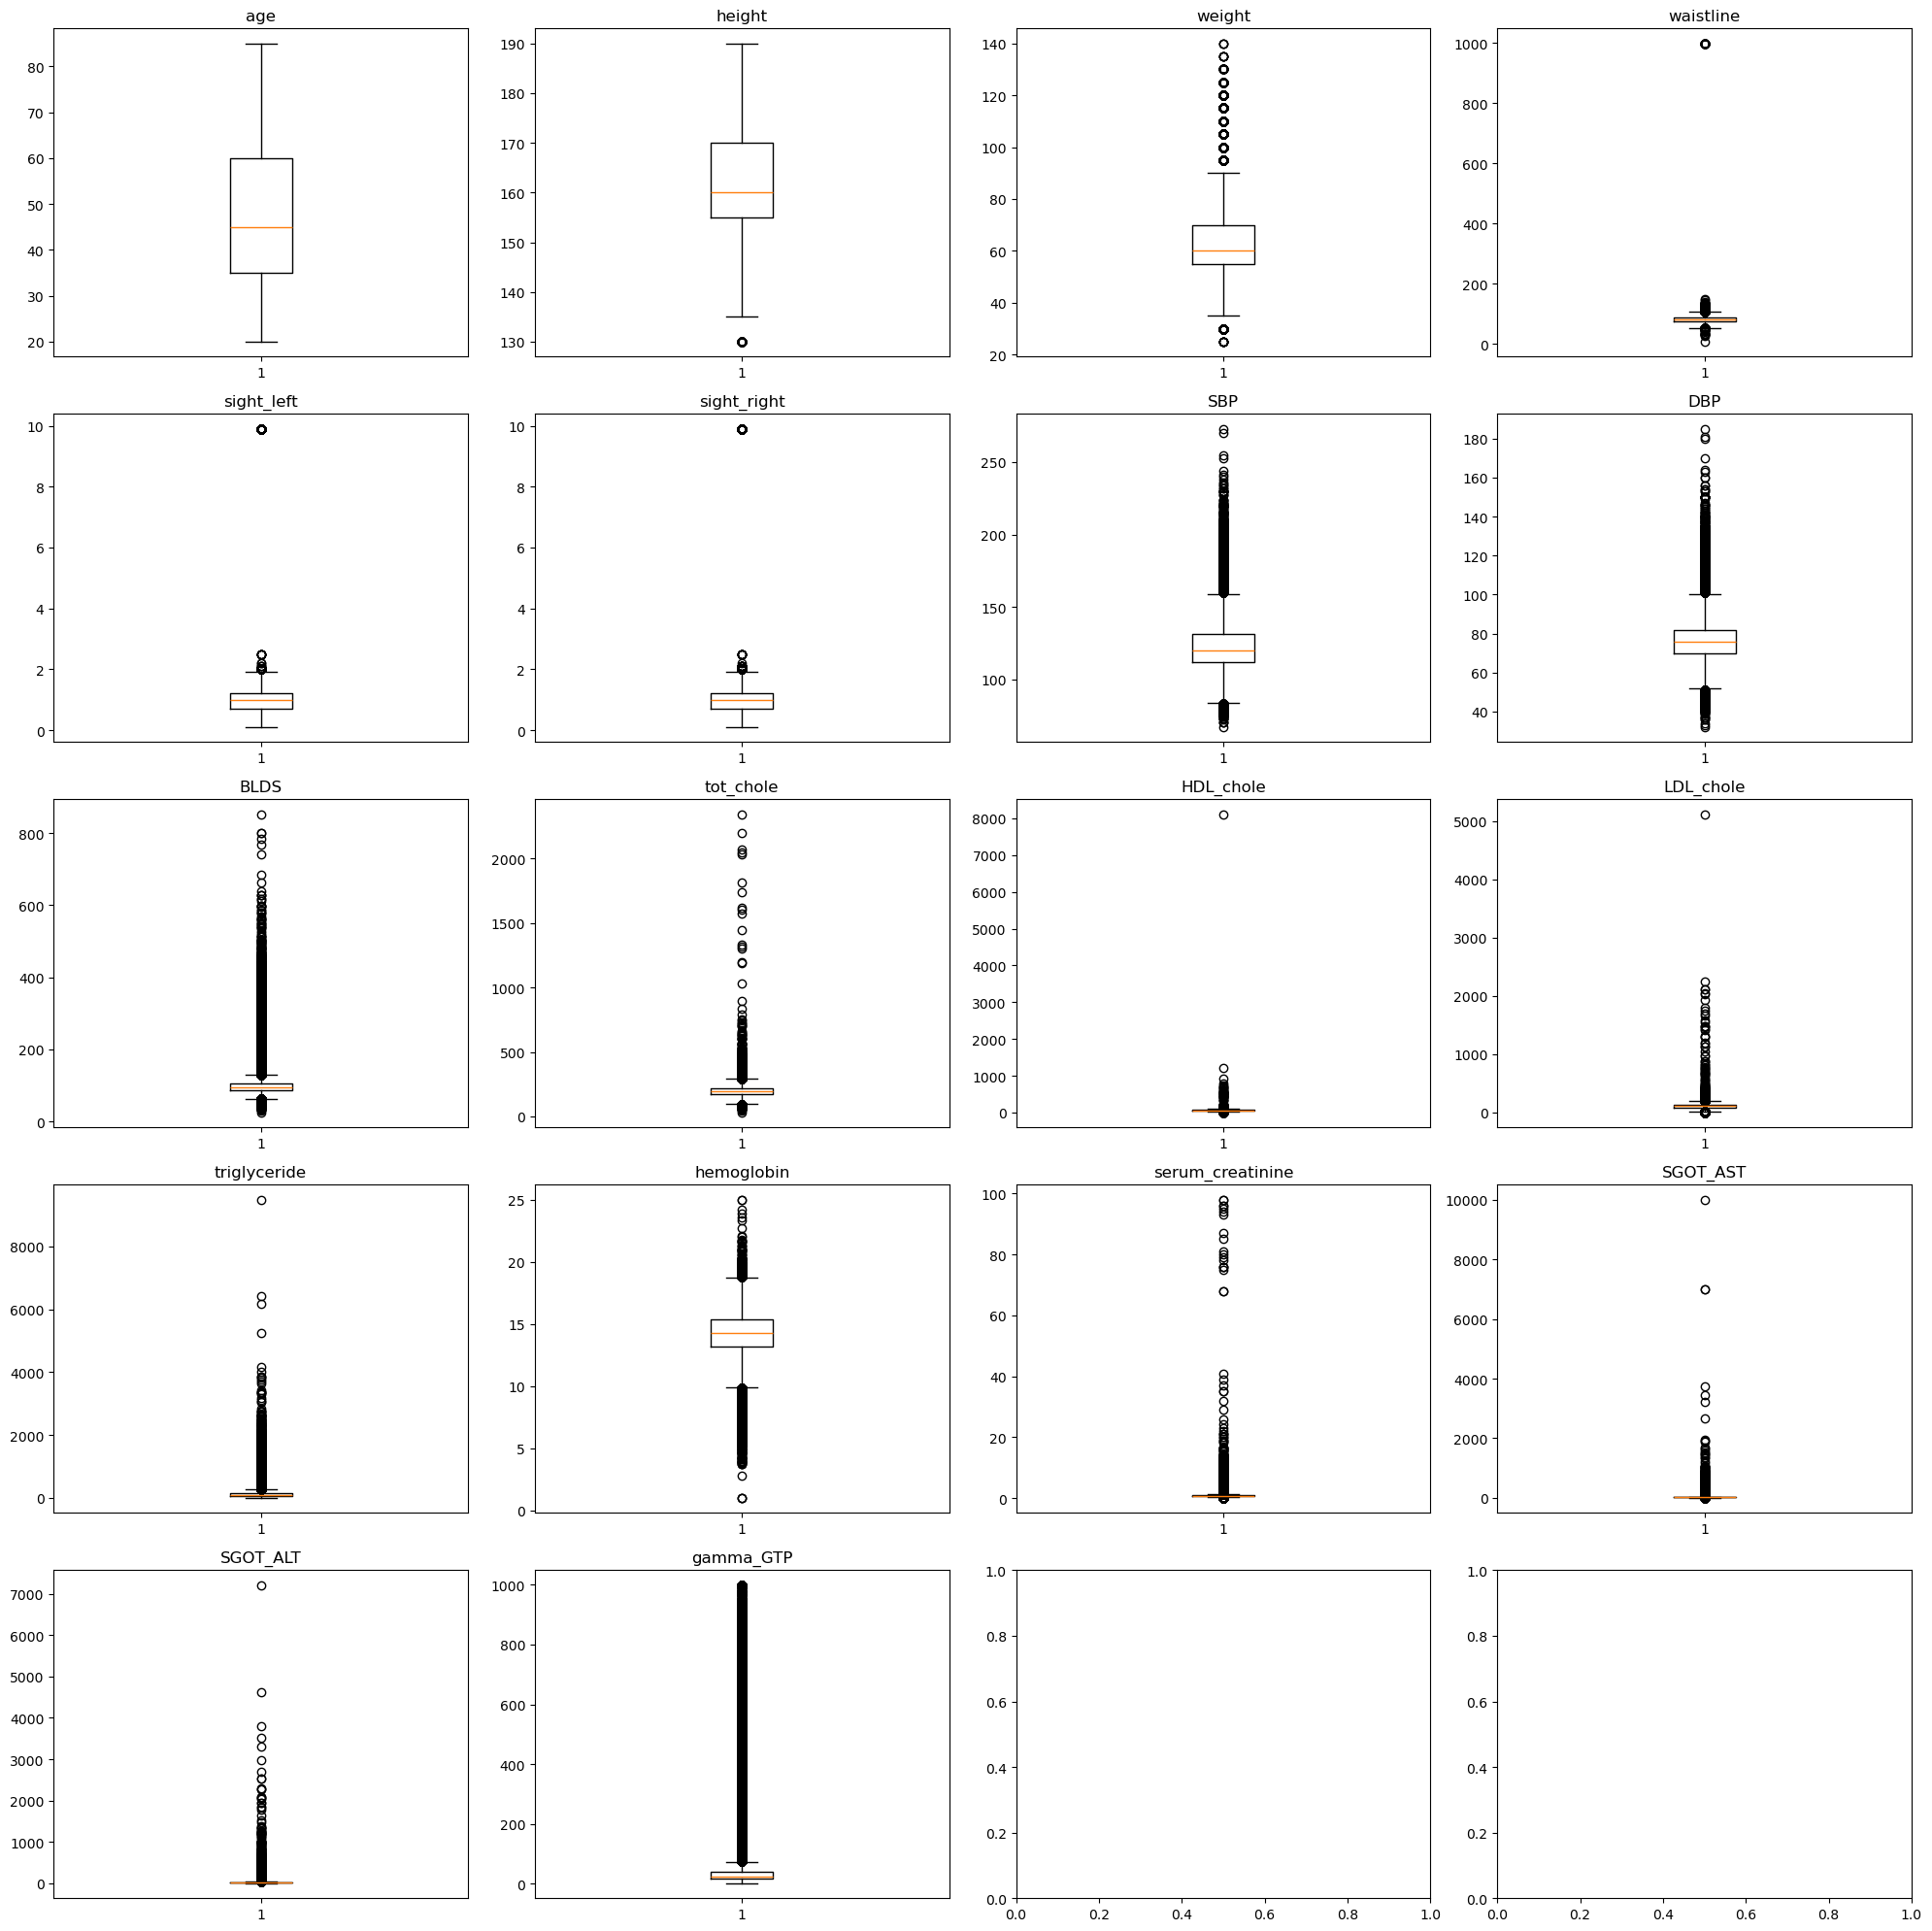

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

### Detect outliers using the IQR method

In [11]:
def iqr_outlier_summary(df, columns):
    summary = []
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
        pct_outliers = n_outliers / len(df) * 100
        summary.append({
            'column': col,
            'lower_bound': lower,
            'upper_bound': upper,
            'n_outliers': n_outliers,
            'pct_outliers': round(pct_outliers, 2)
        })
    return pd.DataFrame(summary)

iqr_summary = iqr_outlier_summary(df, continuous_cols)
iqr_summary

,column,lower_bound,upper_bound,n_outliers,pct_outliers
0,age,-2.50,97.50,0,0.00
1,height,132.50,192.50,86,0.01
2,weight,32.50,92.50,19221,1.94
3,waistline,53.55,108.35,4417,0.45
4,sight_left,-0.05,1.95,11582,1.17
5,sight_right,-0.05,1.95,10495,1.06
6,SBP,83.50,159.50,15836,1.60
7,DBP,52.00,100.00,13122,1.32
8,BLDS,62.50,130.50,64202,6.48
9,tot_chole,94.00,294.00,11298,1.14


### Remove erroneous / sentinel values

In [12]:
# Remove rows with sentinel/erroneous values (data entry errors, not real outliers)
sentinel_conditions = (
    (df['waistline'] > 200) |          # 999 impossible for a waist measurement
    (df['sight_left'] > 3) | (df['sight_right'] > 3) |  # 9.9 outside plausible acuity scale
    (df['HDL_chole'] > 500) |          # 8110 biologically impossible
    (df['LDL_chole'] > 500) |          # 5119 biologically impossible
    (df['serum_creatinine'] > 15) |    # 98 biologically impossible
    (df['SGOT_AST'] > 2000) |          # 9999 sentinel value
    (df['SGOT_ALT'] > 2000) |          # 7210 implausible
    (df['gamma_GTP'] > 700)            # 999 likely sentinel
)

print(f"Rows removed as erroneous: {sentinel_conditions.sum()} ({sentinel_conditions.sum()/len(df)*100:.2f}%)")
df_clean = df[~sentinel_conditions].copy()

Rows removed as erroneous: 6788 (0.68%)


### Cap remaining outliers

In [13]:
# Cap remaining genuine outliers using the IQR bounds (Winsorization)
cols_to_cap = ['weight', 'BLDS', 'tot_chole', 'HDL_chole', 'LDL_chole',
               'triglyceride', 'hemoglobin', 'serum_creatinine',
               'SGOT_AST', 'SGOT_ALT', 'gamma_GTP']

for col in cols_to_cap:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

df_clean[cols_to_cap].describe()

,weight,BLDS,tot_chole,HDL_chole,LDL_chole,triglyceride,hemoglobin,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP
count,984558.000000,984558.000000,984558.000000,984558.000000,984558.000000,984558.000000,984558.000000,984558.000000,984558.000000,984558.000000,984558.000000
mean,63.161693,97.963407,195.310517,56.791400,112.839958,124.500443,14.241698,0.851510,24.382741,23.478129,30.396764
std,12.121216,14.099061,37.193946,14.420196,33.838390,67.558059,1.547964,0.197745,7.606513,11.830922,19.675970
min,32.500000,62.500000,94.000000,16.000000,20.000000,1.000000,9.900000,0.250000,5.500000,1.000000,1.000000
25%,55.000000,88.000000,169.000000,46.000000,89.000000,73.000000,13.200000,0.700000,19.000000,15.000000,16.000000
50%,60.000000,96.000000,193.000000,55.000000,111.000000,106.000000,14.300000,0.800000,23.000000,20.000000,23.000000
75%,70.000000,105.000000,219.000000,66.000000,135.000000,159.000000,15.400000,1.000000,28.000000,29.000000,39.000000
max,92.500000,130.500000,294.000000,96.000000,204.000000,288.000000,18.700000,1.450000,41.500000,50.000000,73.500000


## Task 4 - Data Transformation 

### Encoding Categorical Data

In [ ]:
# Start from the cleaned dataset
df_encoded = df_clean.copy()

# Encode binary categorical variables as 0 and 1
df_encoded["sex"] = df_encoded["sex"].map({
    "Male": 0,
    "Female": 1
})

df_encoded["DRK_YN"] = df_encoded["DRK_YN"].map({
    "N": 0,
    "Y": 1
})

df_encoded["hear_left"] = df_encoded["hear_left"].map({
    1.0: 0,
    2.0: 1
})

df_encoded["hear_right"] = df_encoded["hear_right"].map({
    1.0: 0,
    2.0: 1
})

# One-hot encode smoking status
df_encoded = pd.get_dummies(
    df_encoded,
    columns=["SMK_stat_type_cd"],
    prefix="smoking",
    dtype=int
)

In [ ]:
import pandas as pd

# Display the encoded categorical variables
encoded_cols = [
    "sex",
    "DRK_YN",
    "hear_left",
    "hear_right",
    "urine_protein",
    "smoking_1.0",
    "smoking_2.0",
    "smoking_3.0"
]

df_encoded[encoded_cols].head()

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

df_encoded[encoded_cols].head()

,sex,DRK_YN,hear_left,hear_right,urine_protein,smoking_1.0,smoking_2.0,smoking_3.0
0,0,1,0,0,1.0,1,0,0
1,0,0,0,0,1.0,0,0,1
2,0,0,0,0,1.0,1,0,0
3,0,0,0,0,1.0,1,0,0
4,0,0,0,0,1.0,1,0,0


### Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

# Continuous numerical features to standardize
numerical_cols = [
    "age",
    "height",
    "weight",
    "waistline",
    "sight_left",
    "sight_right",
    "SBP",
    "DBP",
    "BLDS",
    "tot_chole",
    "HDL_chole",
    "LDL_chole",
    "triglyceride",
    "hemoglobin",
    "serum_creatinine",
    "SGOT_AST",
    "SGOT_ALT",
    "gamma_GTP"
]

# Apply Z-score standardization
df_scaled = df_encoded.copy()

scaler = StandardScaler()

df_scaled[numerical_cols] = scaler.fit_transform(
    df_scaled[numerical_cols]
)

In [ ]:
# Summary statistics before standardization
df_encoded[numerical_cols].describe().round(2)

,age,height,weight,waistline,sight_left,sight_right,SBP,DBP,BLDS,tot_chole,HDL_chole,LDL_chole,triglyceride,hemoglobin,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP
count,991346.00,991346.00,991346.00,991346.00,991346.00,991346.00,991346.00,991346.00,991346.00,991346.00,991346.00,991346.00,991346.00,991346.00,991346.00,991346.00,991346.00,991346.00
mean,47.61,162.24,63.28,81.23,0.98,0.98,122.43,76.05,100.42,195.56,56.94,113.04,132.14,14.23,0.86,25.99,25.76,37.14
std,14.18,9.28,12.51,11.85,0.61,0.60,14.54,9.89,24.18,38.66,17.24,35.84,102.20,1.58,0.48,23.49,26.31,50.42
min,20.00,130.00,25.00,8.00,0.10,0.10,67.00,32.00,25.00,30.00,1.00,1.00,1.00,1.00,0.10,1.00,1.00,1.00
25%,35.00,155.00,55.00,74.10,0.70,0.70,112.00,70.00,88.00,169.00,46.00,89.00,73.00,13.20,0.70,19.00,15.00,16.00
50%,45.00,160.00,60.00,81.00,1.00,1.00,120.00,76.00,96.00,193.00,55.00,111.00,106.00,14.30,0.80,23.00,20.00,23.00
75%,60.00,170.00,70.00,87.80,1.20,1.20,131.00,82.00,105.00,219.00,66.00,135.00,159.00,15.40,1.00,28.00,29.00,39.00
max,85.00,190.00,140.00,999.00,9.90,9.90,273.00,185.00,852.00,2344.00,8110.00,5119.00,9490.00,25.00,98.00,9999.00,7210.00,999.00


In [ ]:
# Summary statistics after standardization
df_scaled[numerical_cols].describe().round(2)

,age,height,weight,waistline,sight_left,sight_right,SBP,DBP,BLDS,tot_chole,HDL_chole,LDL_chole,triglyceride,hemoglobin,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP
count,984558.00,984558.00,984558.00,984558.00,984558.00,984558.00,984558.00,984558.00,984558.00,984558.00,984558.00,984558.00,984558.00,984558.00,984558.00,984558.00,984558.00,984558.00
mean,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.00,-0.00,0.00,-0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.95,-3.48,-2.53,-7.63,-2.50,-2.50,-3.61,-4.35,-2.52,-2.72,-2.83,-2.74,-1.83,-2.80,-3.04,-2.48,-1.90,-1.49
25%,-0.89,-0.78,-0.67,-0.75,-0.74,-0.74,-0.72,-0.61,-0.71,-0.71,-0.75,-0.70,-0.76,-0.67,-0.77,-0.71,-0.72,-0.73
50%,-0.18,-0.24,-0.26,-0.02,0.14,0.14,-0.16,-0.00,-0.14,-0.06,-0.12,-0.05,-0.27,0.04,-0.26,-0.18,-0.29,-0.38
75%,0.88,0.83,0.56,0.67,0.72,0.73,0.59,0.60,0.50,0.64,0.64,0.65,0.51,0.75,0.75,0.48,0.47,0.44
max,2.65,2.99,2.42,7.08,4.53,4.56,10.37,11.02,2.31,2.65,2.72,2.69,2.42,2.88,3.03,2.25,2.24,2.19


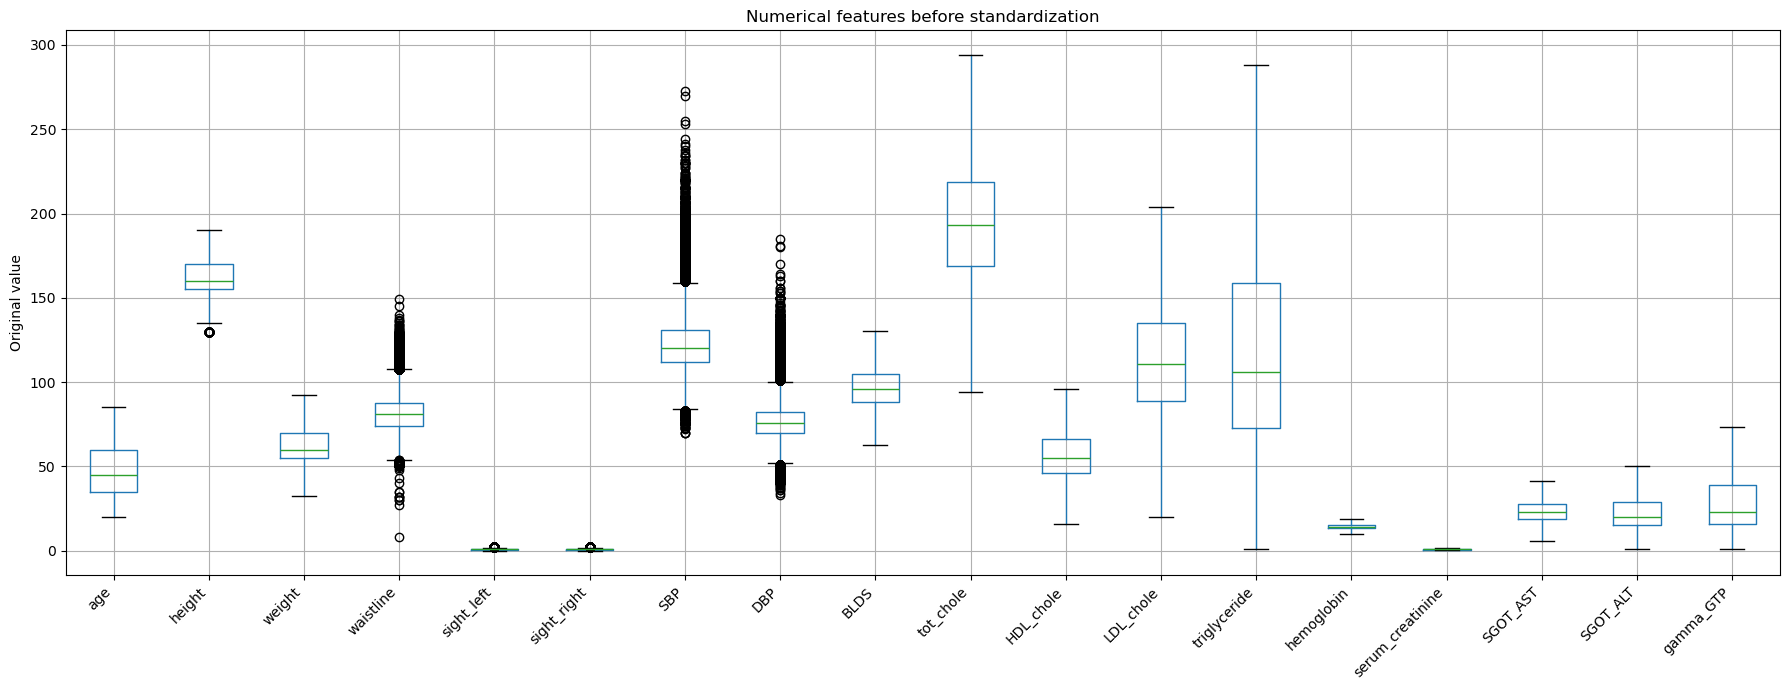

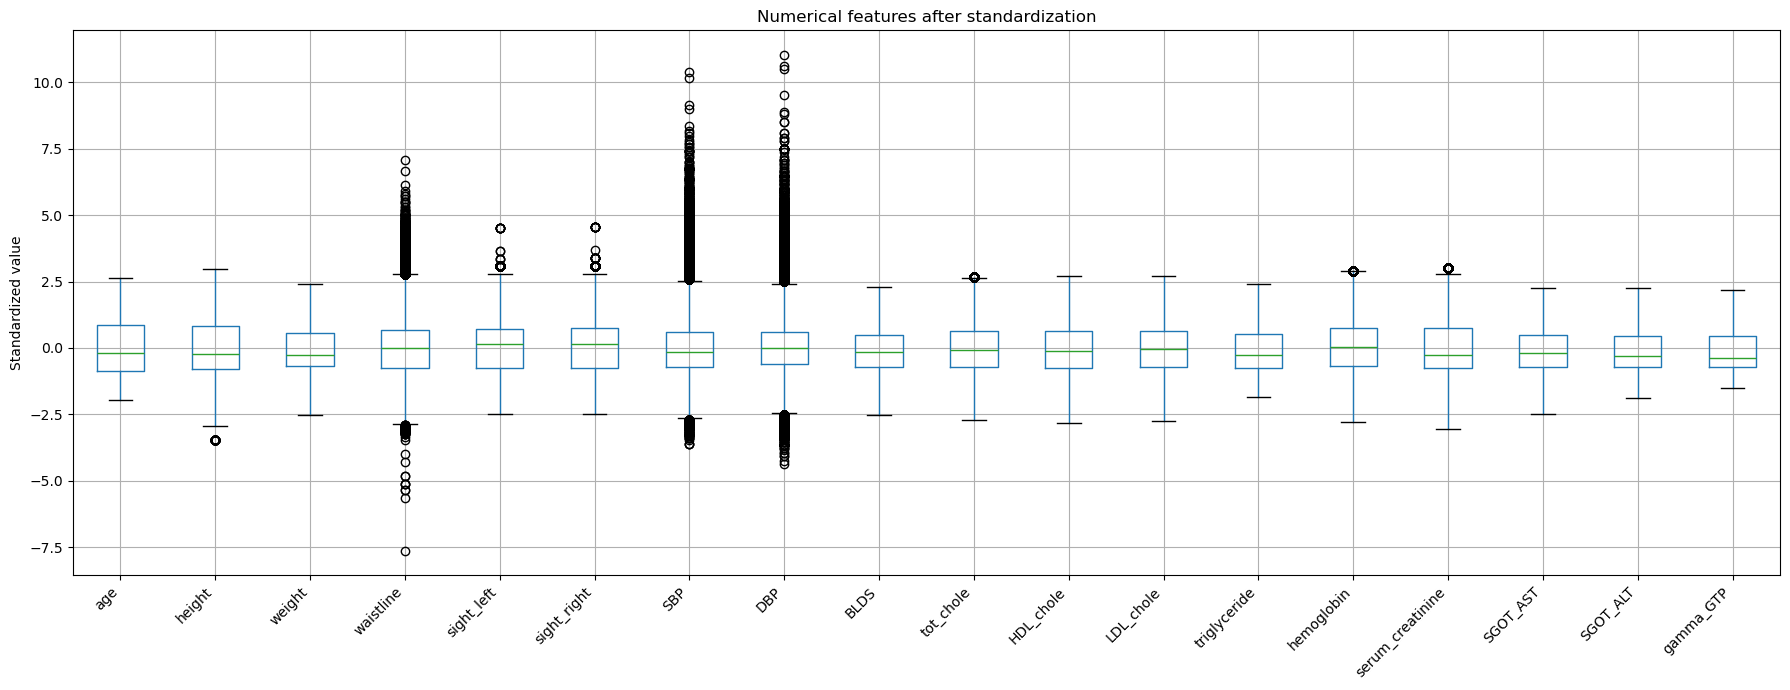

In [40]:
# Compare numerical features before and after standardization
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 7))

df_encoded[numerical_cols].boxplot()

plt.title("Numerical features before standardization")
plt.ylabel("Original value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 7))

df_scaled[numerical_cols].boxplot()

plt.title("Numerical features after standardization")
plt.ylabel("Standardized value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Task 5 - Data Splitting

## Task 6 - Bonus Task